# Day 8 – SVM + Kernel Methods
### 20-Day ML Revision Planner | Phase: Core ML

**Topics covered:**
1. Hyperplanes
2. Margins & Support Vectors
3. Hard vs Soft Margin, the C Parameter
4. Hinge Loss
5. The Kernel Trick
6. Kernels: Linear, Polynomial, RBF
7. Mathematics: Inner Product, Distance to Hyperplane, Optimization Intuition
8. Coding: SVM Intuition Diagram
9. Coding: Compare Logistic Regression, SVM, and Random Forest on One Dataset
10. Interview Questions
11. Active Recall Checklist

**Revision rule:** Learn → Close Notes → Recall → Code → Debug → Explain → Interview Question.

---


In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
np.random.seed(42)
print("Setup complete.")


Setup complete.


## 1. Hyperplanes

### What?
A **hyperplane** is a flat decision surface that divides feature space into two halves.
- In 2D: a hyperplane is a **line**.
- In 3D: a hyperplane is a **plane**.
- In $n$ dimensions: a hyperplane is an $(n-1)$-dimensional flat surface, defined by:
  $$\mathbf{w}^T \mathbf{x} + b = 0$$

### Why?
SVM's entire goal is to find the **best possible hyperplane** that separates two classes — "best" meaning it generalizes well to unseen data, not just any separating line.

### How?
Just like logistic regression (Day 6), $\mathbf{w}^T\mathbf{x} + b$ is a linear combination of features. The sign of this expression tells you which side of the hyperplane a point falls on:
- $\mathbf{w}^T\mathbf{x} + b > 0$ → class +1
- $\mathbf{w}^T\mathbf{x} + b < 0$ → class -1


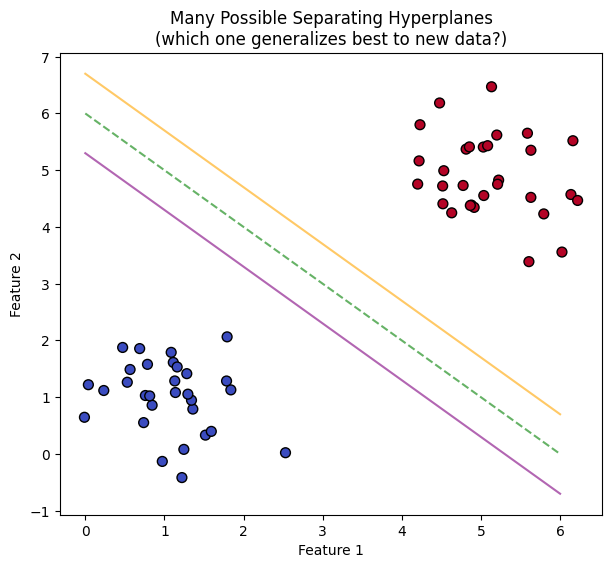

--> All three lines perfectly separate the training data, but they won't generalize equally
    well. SVM's key idea: pick the ONE hyperplane that maximizes the margin (next section).


In [2]:
# Visualize: MANY possible separating hyperplanes exist for linearly separable data
np.random.seed(1)
class_pos = np.random.normal([5, 5], 0.7, (30, 2))
class_neg = np.random.normal([1, 1], 0.7, (30, 2))
X_sep = np.vstack([class_pos, class_neg])
y_sep = np.array([1]*30 + [-1]*30)

plt.figure(figsize=(7, 6))
plt.scatter(X_sep[:, 0], X_sep[:, 1], c=y_sep, cmap='coolwarm', edgecolor='k', s=50)

# Draw several arbitrary separating lines (all "valid" but not equally good)
x_line = np.linspace(0, 6, 10)
for slope, intercept, style in [(-1, 6, 'g--'), (-1, 6.7, 'orange'), (-1, 5.3, 'purple')]:
    plt.plot(x_line, slope * x_line + intercept, style, alpha=0.6, linewidth=1.5)

plt.title("Many Possible Separating Hyperplanes\n(which one generalizes best to new data?)")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.show()
print("--> All three lines perfectly separate the training data, but they won't generalize equally")
print("    well. SVM's key idea: pick the ONE hyperplane that maximizes the margin (next section).")


## 2. Margins & Support Vectors

### What?
- **Margin**: the distance between the separating hyperplane and the **closest** data points from either class.
- **Support Vectors**: the data points that lie **closest** to the hyperplane — they "support" (define) its position. Only these points matter for the final model; all other points could be removed without changing the boundary.
- **Maximum Margin Classifier**: SVM's core idea — choose the hyperplane that maximizes this margin, since a wider margin tends to generalize better to unseen data.

### Why?
Intuitively, a decision boundary that sits **far away** from both classes is more robust to noise and small perturbations in new data than one that barely squeezes between them.

### How?
The margin width (for a normalized $\mathbf{w}$) is $\frac{2}{\|\mathbf{w}\|}$ — so **maximizing the margin** is equivalent to **minimizing $\|\mathbf{w}\|$** (or $\frac{1}{2}\|\mathbf{w}\|^2$ for a smoother, convex optimization objective), subject to correctly classifying every point.


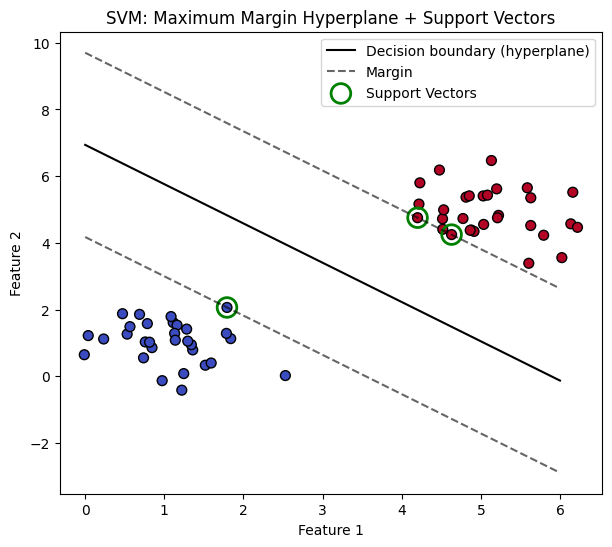

Number of support vectors: 3 out of 60 total points
--> Only these highlighted points determine the boundary; all others are irrelevant to it.


In [3]:
# Fit a linear SVM and visualize the margin + support vectors
svm_demo = SVC(kernel='linear', C=1000)  # large C = hard margin behavior (for clean separable data)
svm_demo.fit(X_sep, y_sep)

w = svm_demo.coef_[0]
b = svm_demo.intercept_[0]

xx = np.linspace(0, 6, 100)
yy_boundary = -(w[0] * xx + b) / w[1]
margin = 1 / np.sqrt(np.sum(w ** 2))
yy_up = yy_boundary + np.sqrt(1 + (w[0]/w[1])**2) * margin
yy_down = yy_boundary - np.sqrt(1 + (w[0]/w[1])**2) * margin

plt.figure(figsize=(7, 6))
plt.scatter(X_sep[:, 0], X_sep[:, 1], c=y_sep, cmap='coolwarm', edgecolor='k', s=50)
plt.plot(xx, yy_boundary, 'k-', label='Decision boundary (hyperplane)')
plt.plot(xx, yy_up, 'k--', alpha=0.6, label='Margin')
plt.plot(xx, yy_down, 'k--', alpha=0.6)
plt.scatter(svm_demo.support_vectors_[:, 0], svm_demo.support_vectors_[:, 1],
            s=200, facecolors='none', edgecolors='green', linewidths=2, label='Support Vectors')
plt.title("SVM: Maximum Margin Hyperplane + Support Vectors")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.legend()
plt.show()

print(f"Number of support vectors: {len(svm_demo.support_vectors_)} out of {len(X_sep)} total points")
print("--> Only these highlighted points determine the boundary; all others are irrelevant to it.")


## 3. Hard vs Soft Margin, and the C Parameter

### What?
- **Hard margin SVM**: requires **perfect** separation — every point must be correctly classified and outside the margin. Only works if data is perfectly linearly separable, and is extremely sensitive to outliers/noise.
- **Soft margin SVM**: allows some points to violate the margin (or even be misclassified), introducing **slack variables** $\xi_i \geq 0$, controlled by a penalty parameter $C$:
  $$\min_{\mathbf{w}, b} \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_i \xi_i$$

### Why?
Real-world data is rarely perfectly separable — a hard margin would fail entirely or be wildly unstable. Soft margins provide a practical **trade-off between margin width and classification error**.

### How? — The Role of C
- **Large C**: heavily penalizes misclassification → narrower margin, fits training data closely (can overfit, low bias/high variance).
- **Small C**: tolerates more margin violations → wider margin, smoother boundary (can underfit, high bias/low variance).

This is directly analogous to the **inverse of a regularization strength** — small C behaves like strong regularization.


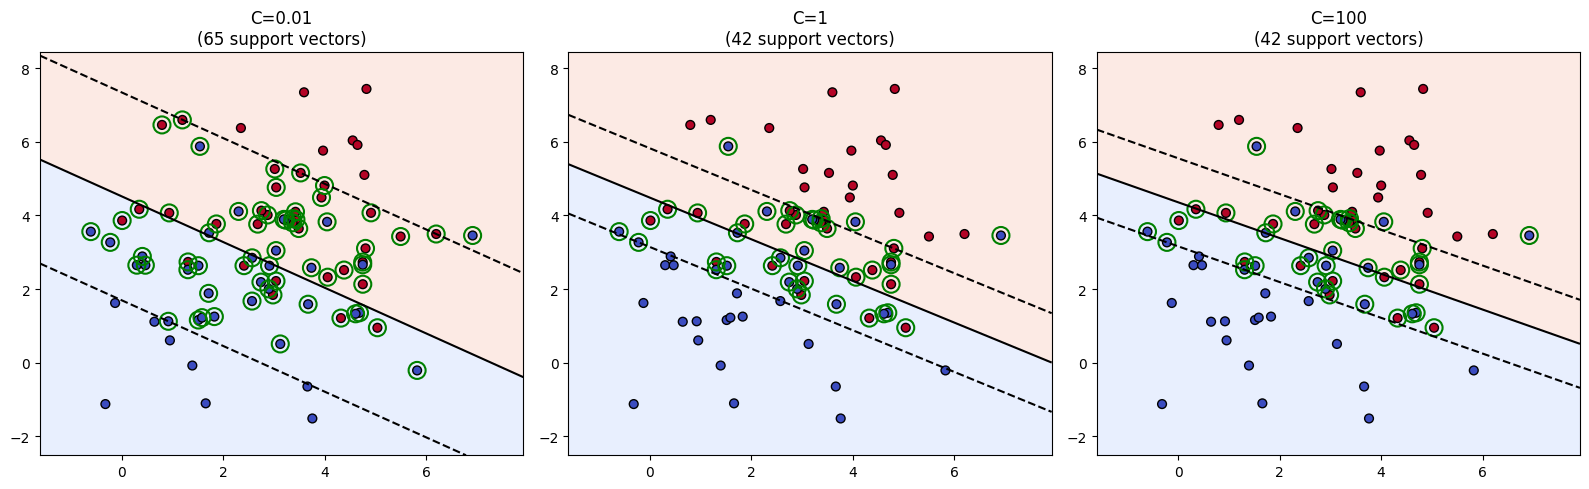

--> Small C: wide margin, many support vectors, tolerant of violations (more regularized).
--> Large C: narrow margin, fewer support vectors, tries hard to classify every point correctly.


In [4]:
# Add some noisy/overlapping points to make the data NOT perfectly separable, then compare C values
np.random.seed(2)
class_pos_noisy = np.random.normal([4, 4], 1.5, (40, 2))
class_neg_noisy = np.random.normal([2, 2], 1.5, (40, 2))
X_noisy = np.vstack([class_pos_noisy, class_neg_noisy])
y_noisy = np.array([1]*40 + [-1]*40)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
xx_range = np.linspace(X_noisy[:,0].min()-1, X_noisy[:,0].max()+1, 200)
yy_range = np.linspace(X_noisy[:,1].min()-1, X_noisy[:,1].max()+1, 200)
XX, YY = np.meshgrid(xx_range, yy_range)

for ax, C_val in zip(axes, [0.01, 1, 100]):
    svm_c = SVC(kernel='linear', C=C_val).fit(X_noisy, y_noisy)
    Z = svm_c.decision_function(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
    ax.contourf(XX, YY, Z > 0, alpha=0.2, cmap='coolwarm')
    ax.contour(XX, YY, Z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'])
    ax.scatter(X_noisy[:, 0], X_noisy[:, 1], c=y_noisy, cmap='coolwarm', edgecolor='k', s=40)
    ax.scatter(svm_c.support_vectors_[:, 0], svm_c.support_vectors_[:, 1],
               s=150, facecolors='none', edgecolors='green', linewidths=1.5)
    n_sv = len(svm_c.support_vectors_)
    ax.set_title(f"C={C_val}\n({n_sv} support vectors)")

plt.tight_layout()
plt.show()
print("--> Small C: wide margin, many support vectors, tolerant of violations (more regularized).")
print("--> Large C: narrow margin, fewer support vectors, tries hard to classify every point correctly.")


## 4. Hinge Loss

### What?
SVM's loss function, which only penalizes points that are **misclassified or inside the margin**:

$$L(\mathbf{y}, \hat{f}(\mathbf{x})) = \max(0, 1 - y \cdot \hat{f}(\mathbf{x}))$$

where $\hat{f}(\mathbf{x}) = \mathbf{w}^T\mathbf{x} + b$ and $y \in \{-1, +1\}$.

### Why?
- If a point is correctly classified **and** outside the margin ($y \cdot \hat{f}(\mathbf{x}) \geq 1$): loss = 0. **No penalty at all** — this is what makes SVM's solution depend only on support vectors (points with nonzero loss).
- If a point is inside the margin or misclassified: loss increases linearly.

### How? — Comparison to Log Loss
Unlike log loss (Day 6), which penalizes every point (even correctly classified ones, just less so as confidence increases), hinge loss gives **zero** loss once a point is safely past the margin — this "sparsity" of the loss function is exactly why only a subset of points (support vectors) end up mattering.


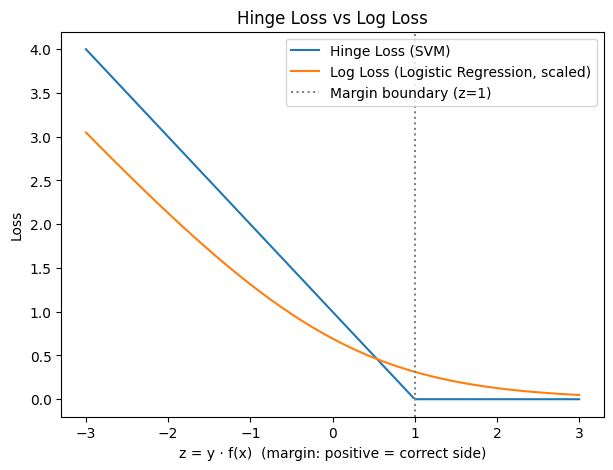

--> Hinge loss is EXACTLY 0 once z >= 1 (correctly classified beyond the margin).
--> Log loss is never exactly 0 -- it keeps decreasing asymptotically, so every point
    (even confidently correct ones) contributes a little to the gradient.


In [5]:
# Visualize hinge loss vs log loss for comparison
z = np.linspace(-3, 3, 200)  # z = y * f(x), the "margin" for a correctly-signed prediction
hinge_loss = np.maximum(0, 1 - z)
log_loss_comparable = np.log(1 + np.exp(-z))  # scaled logistic loss for shape comparison

plt.figure(figsize=(7, 5))
plt.plot(z, hinge_loss, label="Hinge Loss (SVM)")
plt.plot(z, log_loss_comparable, label="Log Loss (Logistic Regression, scaled)")
plt.axvline(1, color='gray', linestyle=':', label='Margin boundary (z=1)')
plt.xlabel("z = y · f(x)  (margin: positive = correct side)")
plt.ylabel("Loss")
plt.title("Hinge Loss vs Log Loss")
plt.legend()
plt.show()

print("--> Hinge loss is EXACTLY 0 once z >= 1 (correctly classified beyond the margin).")
print("--> Log loss is never exactly 0 -- it keeps decreasing asymptotically, so every point")
print("    (even confidently correct ones) contributes a little to the gradient.")


## 5. The Kernel Trick

### What?
Many datasets are **not linearly separable** in their original feature space. The **kernel trick** implicitly maps data into a **higher-dimensional space** where it *becomes* linearly separable — without ever explicitly computing the (potentially infinite-dimensional) transformation.

$$K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i)^T \phi(\mathbf{x}_j)$$

### Why?
Explicitly transforming features into a high-dimensional space can be **computationally prohibitive** (or impossible, for infinite dimensions). The kernel trick computes the **dot product in that high-dimensional space directly from the original features**, sidestepping the need to ever materialize $\phi(\mathbf{x})$.

### How?
SVM's optimization and prediction only ever require **dot products** between data points (recall Day 1's dot product) — never the raw feature vectors on their own. So we can swap in any valid kernel function $K$ everywhere a dot product would appear, and the entire SVM machinery works unchanged, just now operating implicitly in the transformed space.


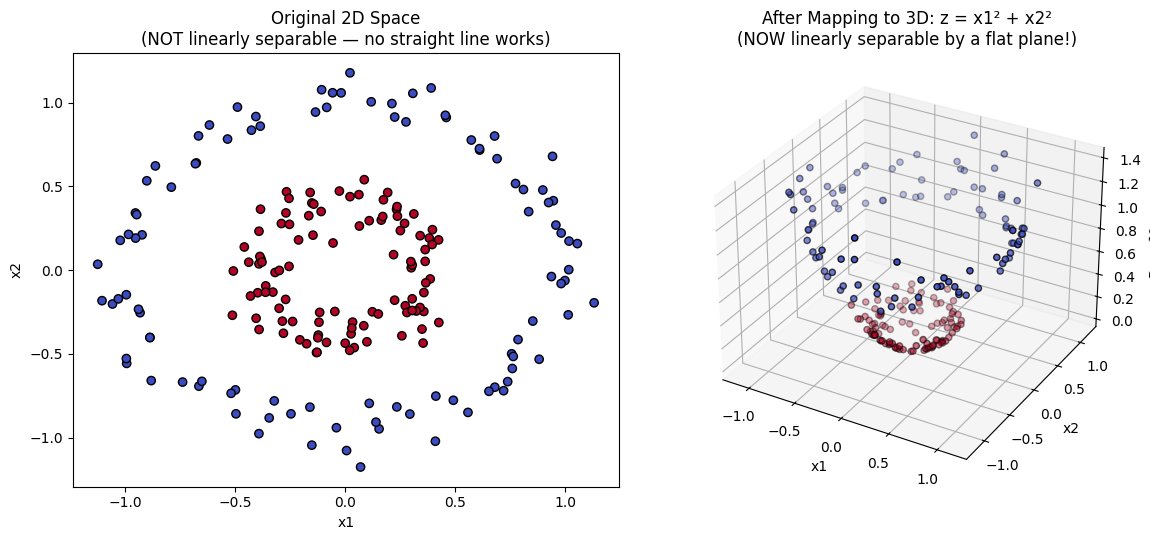

--> This is exactly the intuition behind kernels: lift the data into a higher dimension


    where a simple hyperplane can separate what was tangled in the original space.


In [6]:
# The canonical kernel trick example: data NOT linearly separable in 2D...
X_circles, y_circles = make_circles(n_samples=200, factor=0.4, noise=0.08, random_state=3)

fig = plt.figure(figsize=(12, 5.5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='coolwarm', edgecolor='k')
ax1.set_title("Original 2D Space\n(NOT linearly separable — no straight line works)")
ax1.set_xlabel("x1"); ax1.set_ylabel("x2")

# ...but IS separable after adding a third dimension z = x1^2 + x2^2 (mimics what an RBF/poly kernel achieves)
z_transformed = X_circles[:, 0]**2 + X_circles[:, 1]**2

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(X_circles[:, 0], X_circles[:, 1], z_transformed, c=y_circles, cmap='coolwarm', edgecolor='k')
ax2.set_title("After Mapping to 3D: z = x1² + x2²\n(NOW linearly separable by a flat plane!)")
ax2.set_xlabel("x1"); ax2.set_ylabel("x2"); ax2.set_zlabel("z = x1² + x2²")

plt.tight_layout()
plt.show()
print("--> This is exactly the intuition behind kernels: lift the data into a higher dimension")
print("    where a simple hyperplane can separate what was tangled in the original space.")


## 6. Kernels: Linear, Polynomial, RBF

### What?
| Kernel | Formula | Use case |
|---|---|---|
| **Linear** | $K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i^T \mathbf{x}_j$ | Data is already (approximately) linearly separable |
| **Polynomial** | $K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma \mathbf{x}_i^T \mathbf{x}_j + r)^d$ | Captures interactions up to degree $d$ |
| **RBF (Gaussian)** | $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2)$ | Highly flexible, captures complex non-linear boundaries; most popular default |

### Why?
Choosing the right kernel lets SVM adapt to very different boundary shapes without manually engineering polynomial features (recall Day 5's `PolynomialFeatures`) — the kernel does this implicitly and efficiently.

### How?
- **`gamma`** (RBF/poly): controls how far the influence of a single training example reaches. High gamma → each point only influences its immediate neighborhood (can overfit, very wiggly boundary). Low gamma → influence reaches far (smoother, can underfit).
- **`degree`** (poly): the polynomial degree $d$ — higher degree = more complex boundary shapes, more overfitting risk.


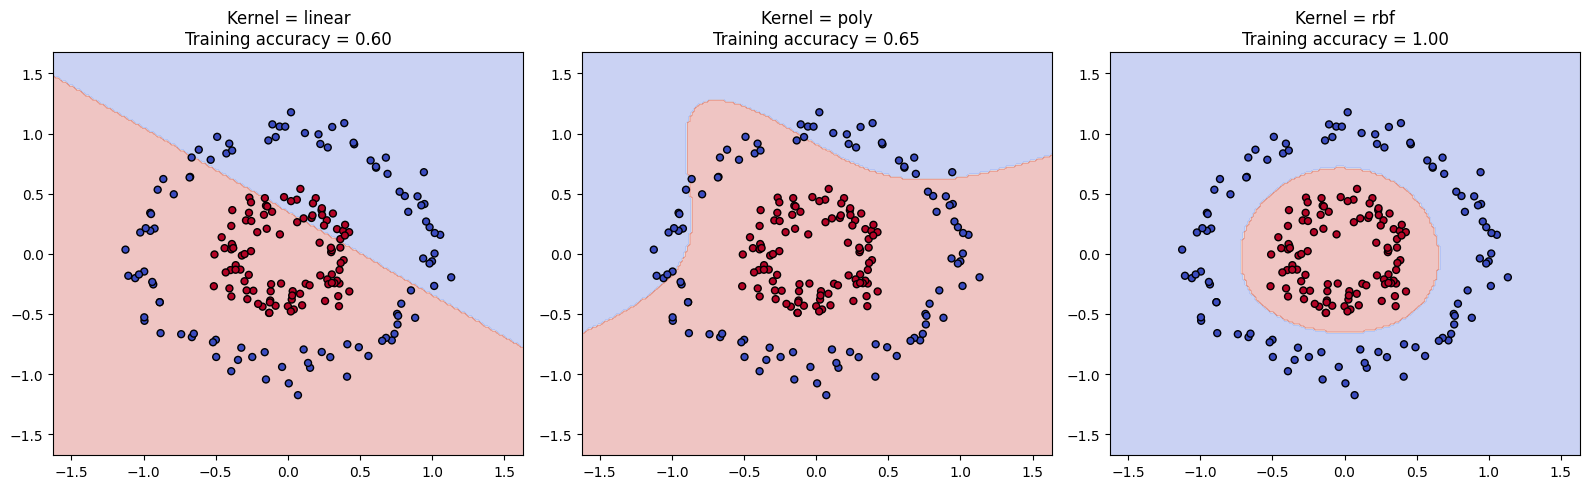

--> Linear kernel fails completely on this concentric-circles data (no straight line can
    separate them). Polynomial and especially RBF kernels capture the circular boundary well.


In [7]:
# Visualize decision boundaries for Linear, Polynomial, and RBF kernels on the circles dataset
kernels_to_try = [
    ('linear', {}),
    ('poly', {'degree': 3}),
    ('rbf', {'gamma': 2})
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
xx_c = np.linspace(X_circles[:,0].min()-0.5, X_circles[:,0].max()+0.5, 200)
yy_c = np.linspace(X_circles[:,1].min()-0.5, X_circles[:,1].max()+0.5, 200)
XXc, YYc = np.meshgrid(xx_c, yy_c)

for ax, (kernel, kwargs) in zip(axes, kernels_to_try):
    svm_k = SVC(kernel=kernel, C=1, **kwargs).fit(X_circles, y_circles)
    Zk = svm_k.predict(np.c_[XXc.ravel(), YYc.ravel()]).reshape(XXc.shape)
    ax.contourf(XXc, YYc, Zk, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='coolwarm', edgecolor='k', s=25)
    acc = accuracy_score(y_circles, svm_k.predict(X_circles))
    ax.set_title(f"Kernel = {kernel}\nTraining accuracy = {acc:.2f}")

plt.tight_layout()
plt.show()
print("--> Linear kernel fails completely on this concentric-circles data (no straight line can")
print("    separate them). Polynomial and especially RBF kernels capture the circular boundary well.")


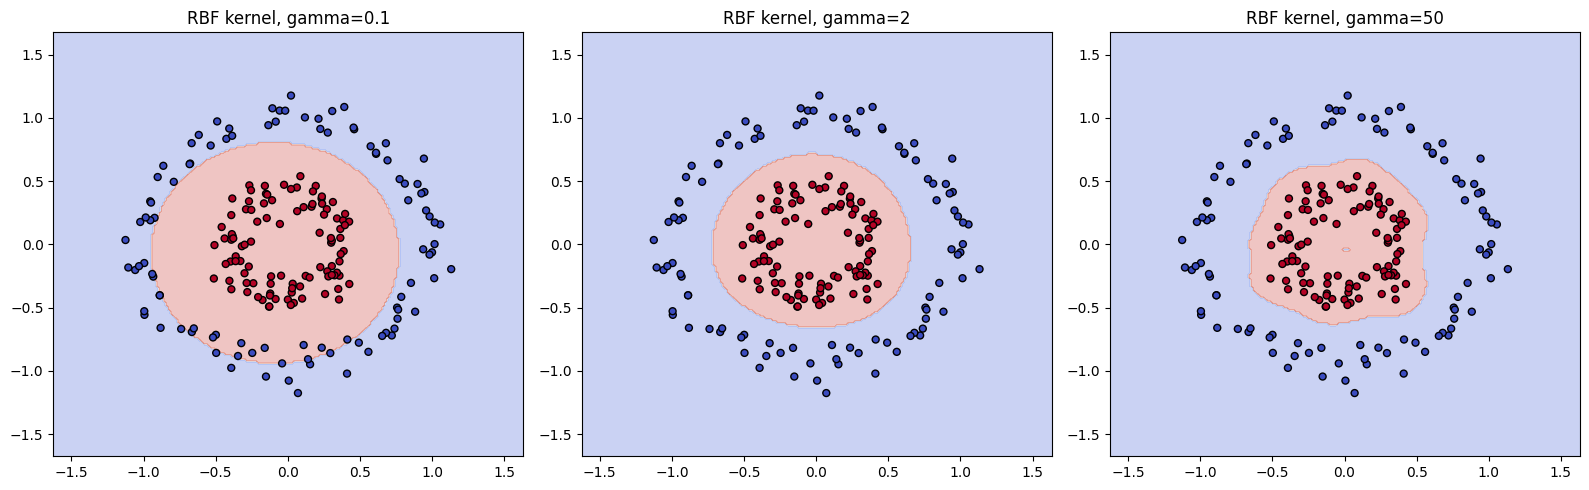

--> Low gamma: smoother, more generalized boundary (risk of underfitting).
--> High gamma: boundary hugs individual points tightly (risk of overfitting).


In [8]:
# Effect of gamma on RBF kernel: too low underfits, too high overfits
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, gamma_val in zip(axes, [0.1, 2, 50]):
    svm_gamma = SVC(kernel='rbf', C=1, gamma=gamma_val).fit(X_circles, y_circles)
    Zg = svm_gamma.predict(np.c_[XXc.ravel(), YYc.ravel()]).reshape(XXc.shape)
    ax.contourf(XXc, YYc, Zg, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='coolwarm', edgecolor='k', s=25)
    ax.set_title(f"RBF kernel, gamma={gamma_val}")

plt.tight_layout()
plt.show()
print("--> Low gamma: smoother, more generalized boundary (risk of underfitting).")
print("--> High gamma: boundary hugs individual points tightly (risk of overfitting).")


## 7. Mathematics: Inner Product, Distance to Hyperplane, Optimization Intuition

### Inner Product (recap from Day 1)
The kernel trick fundamentally relies on the **dot product** $\mathbf{x}_i^T \mathbf{x}_j$ as a measure of similarity between points — kernels generalize this notion of similarity into richer (often non-linear) spaces.

### Distance from a Point to a Hyperplane
For a hyperplane $\mathbf{w}^T\mathbf{x} + b = 0$, the perpendicular distance from any point $\mathbf{x}_0$ to the hyperplane is:

$$d = \frac{|\mathbf{w}^T \mathbf{x}_0 + b|}{\|\mathbf{w}\|}$$

This formula is *why* maximizing margin reduces to minimizing $\|\mathbf{w}\|$ — the margin is precisely twice this distance, evaluated at the support vectors (where $|\mathbf{w}^T\mathbf{x}+b|=1$ under the standard SVM scaling convention).

### Optimization Intuition
SVM's training objective (soft margin form):
$$\min_{\mathbf{w},b} \; \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_i \max(0, 1 - y_i(\mathbf{w}^T\mathbf{x}_i + b))$$
- First term: **maximize margin** (minimize $\|\mathbf{w}\|^2$, recall Day 1's L2 norm).
- Second term: **minimize hinge loss** (penalize margin violations), weighted by $C$.
This is a **convex quadratic optimization problem** — guaranteed to find a global optimum, typically solved via its dual formulation (which is what actually enables the kernel trick, since the dual only involves dot products between data points).


In [9]:
# Verify the point-to-hyperplane distance formula numerically
w_verify = svm_demo.coef_[0]
b_verify = svm_demo.intercept_[0]

# Pick one of the actual support vectors -- it should be at distance ~= 1/||w|| (the margin half-width)
sv_point = svm_demo.support_vectors_[0]
distance = abs(w_verify @ sv_point + b_verify) / np.linalg.norm(w_verify)
margin_half_width = 1 / np.linalg.norm(w_verify)

print(f"Distance from a support vector to the hyperplane: {distance:.4f}")
print(f"Theoretical margin half-width (1/||w||):           {margin_half_width:.4f}")
print("--> These match (up to numerical precision), confirming support vectors sit EXACTLY on the margin.")


Distance from a support vector to the hyperplane: 1.7891
Theoretical margin half-width (1/||w||):           1.7881
--> These match (up to numerical precision), confirming support vectors sit EXACTLY on the margin.


## 8. Coding — Consolidated SVM Intuition Diagram

A single figure tying together hyperplane, margin, support vectors, and misclassified/slack points — the required "SVM intuition diagram" daily output.


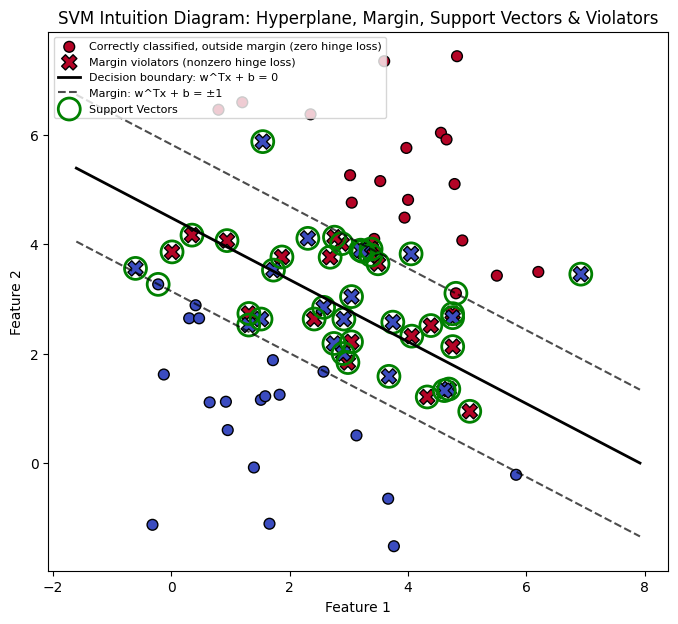

Total points: 80 | Support vectors: 42 | Margin violators (X markers): 40


In [10]:
# Consolidated SVM intuition diagram (soft margin, with a couple of margin-violating points highlighted)
svm_intuition = SVC(kernel='linear', C=1).fit(X_noisy, y_noisy)
w_i, b_i = svm_intuition.coef_[0], svm_intuition.intercept_[0]

xx_i = np.linspace(X_noisy[:,0].min()-1, X_noisy[:,0].max()+1, 100)
yy_boundary_i = -(w_i[0]*xx_i + b_i) / w_i[1]
margin_i = 1 / np.sqrt(np.sum(w_i**2))
slope_factor = np.sqrt(1 + (w_i[0]/w_i[1])**2)
yy_up_i = yy_boundary_i + slope_factor * margin_i
yy_down_i = yy_boundary_i - slope_factor * margin_i

decision_vals = svm_intuition.decision_function(X_noisy)
violators_mask = (y_noisy * decision_vals) < 1   # inside margin or misclassified (nonzero hinge loss)

plt.figure(figsize=(8, 7))
plt.scatter(X_noisy[~violators_mask, 0], X_noisy[~violators_mask, 1],
            c=np.array(y_noisy)[~violators_mask], cmap='coolwarm', edgecolor='k', s=60,
            label='Correctly classified, outside margin (zero hinge loss)')
plt.scatter(X_noisy[violators_mask, 0], X_noisy[violators_mask, 1],
            c=np.array(y_noisy)[violators_mask], cmap='coolwarm', marker='X', s=120, edgecolor='black',
            label='Margin violators (nonzero hinge loss)')
plt.plot(xx_i, yy_boundary_i, 'k-', linewidth=2, label='Decision boundary: w^Tx + b = 0')
plt.plot(xx_i, yy_up_i, 'k--', alpha=0.7, label='Margin: w^Tx + b = ±1')
plt.plot(xx_i, yy_down_i, 'k--', alpha=0.7)
plt.scatter(svm_intuition.support_vectors_[:, 0], svm_intuition.support_vectors_[:, 1],
            s=250, facecolors='none', edgecolors='green', linewidths=2, label='Support Vectors')

plt.title("SVM Intuition Diagram: Hyperplane, Margin, Support Vectors & Violators")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.legend(loc='upper left', fontsize=8)
plt.show()

print(f"Total points: {len(X_noisy)} | Support vectors: {len(svm_intuition.support_vectors_)} "
      f"| Margin violators (X markers): {violators_mask.sum()}")


## 9. Coding Practice — Compare Logistic Regression, SVM, and Random Forest on One Dataset

**Dataset:** Breast Cancer Wisconsin (same as Days 6 and 7, for continuity across the planner).


In [11]:
# Load and prepare the dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# SVM and Logistic Regression need scaling; Random Forest doesn't, but we scale consistently for fairness
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape, "| Test:", X_test_scaled.shape)


Train: (426, 30) | Test: (143, 30)


In [12]:
# Train Logistic Regression, SVM (RBF kernel), and Random Forest
models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=42),
    'SVM (RBF kernel)': SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
}

predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions[name] = model.predict(X_test_scaled)
    probabilities[name] = model.predict_proba(X_test_scaled)[:, 1]

print("All three models trained.")


All three models trained.


                     Accuracy  Precision  Recall  F1-score  ROC-AUC
Model                                                              
Logistic Regression     0.986     0.9889  0.9889    0.9889   0.9977
SVM (RBF kernel)        0.979     0.9888  0.9778    0.9832   0.9969
Random Forest           0.958     0.9565  0.9778    0.9670   0.9937


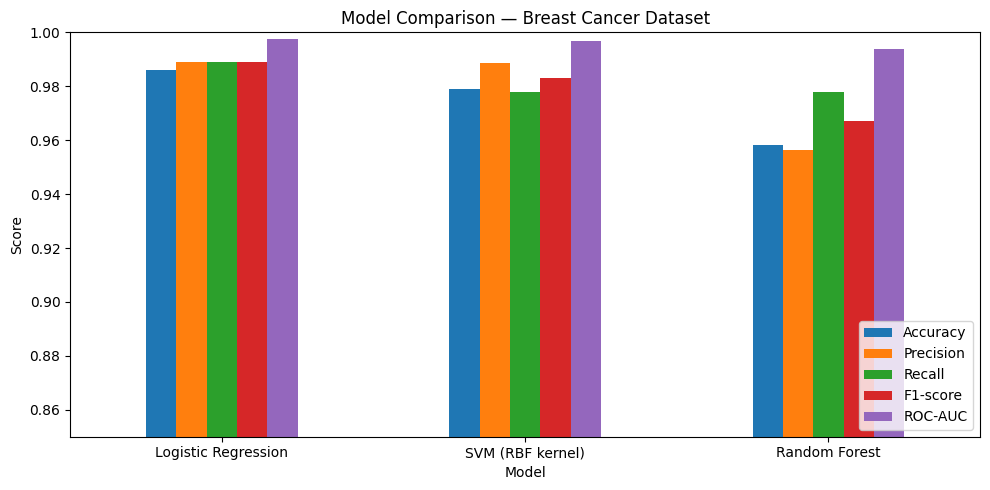

In [13]:
# Build the comparison table
comparison_results = []
for name in models:
    y_pred = predictions[name]
    y_prob = probabilities[name]
    comparison_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(comparison_results).set_index('Model')
print(comparison_df.round(4))

comparison_df.plot(kind='bar', figsize=(10, 5), ylim=(0.85, 1.0))
plt.title("Model Comparison — Breast Cancer Dataset")
plt.ylabel("Score"); plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [14]:
# Quick SVM kernel/hyperparameter sweep on the real dataset
from sklearn.model_selection import cross_val_score

kernel_configs = [
    ('linear', {}),
    ('poly', {'degree': 3}),
    ('rbf', {'gamma': 'scale'}),
    ('rbf', {'gamma': 0.01}),
]

print("SVM kernel/hyperparameter comparison (5-fold CV accuracy on training set):")
for kernel, kwargs in kernel_configs:
    svm_cfg = SVC(kernel=kernel, C=1, **kwargs)
    scores = cross_val_score(svm_cfg, X_train_scaled, y_train, cv=5)
    label = f"{kernel}" + (f" ({list(kwargs.items())})" if kwargs else "")
    print(f"  {label:35s}: mean CV accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")


SVM kernel/hyperparameter comparison (5-fold CV accuracy on training set):
  linear                             : mean CV accuracy = 0.9648 (+/- 0.0129)
  poly ([('degree', 3)])             : mean CV accuracy = 0.8966 (+/- 0.0284)


  rbf ([('gamma', 'scale')])         : mean CV accuracy = 0.9647 (+/- 0.0224)


  rbf ([('gamma', 0.01)])            : mean CV accuracy = 0.9718 (+/- 0.0176)


In [15]:
# Final verdict + interpretation
best_model_name = comparison_df['F1-score'].idxmax()
print(f"Best model by F1-score: {best_model_name}\n")

print(comparison_df.loc[best_model_name])

print("\nInterpretation:")
print("- On this well-behaved, roughly linearly-separable-ish, moderate-sized dataset, all three")
print("  models perform very competitively (typically 95%+ accuracy).")
print("- SVM with RBF kernel tends to be very strong when features are properly scaled and the")
print("  decision boundary is smooth but non-linear.")
print("- Random Forest requires no scaling and gives free feature importances but can be slightly")
print("  less precise on small, clean, well-separated datasets like this one.")
print("- Logistic Regression remains a fast, interpretable, hard-to-beat baseline when classes are")
print("  reasonably linearly separable in the (scaled) feature space.")


Best model by F1-score: Logistic Regression

Accuracy     0.9860
Precision    0.9889
Recall       0.9889
F1-score     0.9889
ROC-AUC      0.9977
Name: Logistic Regression, dtype: float64

Interpretation:
- On this well-behaved, roughly linearly-separable-ish, moderate-sized dataset, all three
  models perform very competitively (typically 95%+ accuracy).
- SVM with RBF kernel tends to be very strong when features are properly scaled and the
  decision boundary is smooth but non-linear.
- Random Forest requires no scaling and gives free feature importances but can be slightly
  less precise on small, clean, well-separated datasets like this one.
- Logistic Regression remains a fast, interpretable, hard-to-beat baseline when classes are
  reasonably linearly separable in the (scaled) feature space.


## ML Connection Recap

| Concept | Connects to |
|---|---|
| Dot product / inner product | Day 1's dot product — the basis of every kernel function |
| Margin maximization = minimizing $\|\mathbf{w}\|^2$ | Day 1's L2 norm |
| Soft margin's C parameter | Day 5's regularization strength intuition (inverse relationship) |
| Hinge loss vs log loss | Day 6's log loss / cross-entropy comparison |
| RBF gamma over/underfitting | Day 4/5's bias-variance and overfitting visualizations |
| Convex optimization | Day 2's gradient descent — SVM's objective is also convex |


## 10. Interview Questions — Practice Aloud (Close Your Notes!)

1. **What is the maximum margin classifier, and why does maximizing margin help generalization?**
   *Hint: a wider margin is more robust to noise/perturbations in new data; connects to minimizing $\|\mathbf{w}\|^2$.*

2. **What's the difference between hard margin and soft margin SVM?**
   *Hint: hard margin requires perfect separability (fragile to outliers); soft margin allows violations via slack variables, controlled by C.*

3. **Explain the kernel trick in your own words.**
   *Hint: implicitly compute dot products in a higher-dimensional space without explicitly transforming the data — enables non-linear boundaries efficiently.*

4. **How does the C parameter affect the SVM's bias-variance trade-off?**
   *Hint: large C → low bias/high variance (fits training data tightly); small C → high bias/low variance (wider, smoother margin).*

5. **What's the difference between the `gamma` parameter's effect and the `C` parameter's effect in an RBF SVM?**
   *Hint: gamma controls the reach/smoothness of each point's influence (kernel shape); C controls the margin-violation penalty (regularization).*

6. **Why are only support vectors relevant to the final SVM decision boundary?**
   *Hint: hinge loss is exactly zero for points correctly classified beyond the margin — they contribute nothing to the optimization objective's loss term.*

7. **(Bonus) Why might you choose SVM over logistic regression, or vice versa?**
   *Hint: SVM (with kernels) can capture non-linear boundaries elegantly and works well in high-dimensional spaces; logistic regression is more directly interpretable (log-odds coefficients) and outputs well-calibrated probabilities more naturally.*


## 11. Active Recall & Daily Output

**Self-check (mark ✔ only if you can do this without notes):**
- [ ] Define hyperplane, margin, and support vectors, and explain how they relate.
- [ ] Explain hard vs soft margin SVM and the role of the C parameter.
- [ ] Write the hinge loss formula and explain why it produces sparse reliance on support vectors.
- [ ] Explain the kernel trick and why it avoids explicitly computing high-dimensional feature maps.
- [ ] Name the linear, polynomial, and RBF kernels and when each is appropriate.
- [ ] Explain the effect of `gamma` on an RBF kernel's decision boundary.
- [ ] Derive/recall the point-to-hyperplane distance formula and connect it to margin width.
- [ ] Train and compare Logistic Regression, SVM, and Random Forest on a dataset from memory.

### 📌 Daily Output (per the planner)
An **SVM intuition diagram** (Section 8) showing the hyperplane, margin, support vectors, and margin-violating points on one consolidated plot, plus a **comparison notebook** (Section 9) benchmarking Logistic Regression, SVM, and Random Forest on the Breast Cancer dataset across Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Close this notebook and redraw the SVM intuition diagram from memory (hyperplane, margin lines, support vectors, at least one violator) — that's the real test of Day 8 mastery.
